<a href="https://colab.research.google.com/github/gabrielpe47/Remover_Fundo_Anime/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalar Dependências
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python pillow matplotlib huggingface-hub
!pip install pytorch-lightning
!pip install kornia

In [ ]:
# Clonar o repositório
!git clone https://github.com/SkyTNT/anime-segmentation.git
%cd anime-segmentation

Cloning into 'anime-segmentation'...
remote: Enumerating objects: 334, done.
remote: Counting objects: 100% (185/185), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 334 (delta 156), reused 151 (delta 151), pack-reused 149 (from 1)
Receiving objects: 100% (334/334), 14.02 MiB | 7.93 MiB/s, done.
Resolving deltas: 100% (219/219), done.
/content/anime-segmentation/anime-segmentation


In [ ]:
# Importar bibliotecas
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.cuda import amp
from huggingface_hub import hf_hub_download
from train import AnimeSegmentation

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
#Criar Máscara
def get_mask(model, input_img, use_amp=True, s=640):
    """Gera máscara de segmentação para a imagem"""
    input_img = (input_img / 255).astype(np.float32)
    h, w = h0, w0 = input_img.shape[:-1]
    h, w = (s, int(s * w / h)) if h > w else (int(s * h / w), s)
    ph, pw = s - h, s - w
    img_input = np.zeros([s, s, 3], dtype=np.float32)
    img_input[ph // 2:ph // 2 + h, pw // 2:pw // 2 + w] = cv2.resize(input_img, (w, h))
    img_input = np.transpose(img_input, (2, 0, 1))
    img_input = img_input[np.newaxis, :]

    tmpImg = torch.from_numpy(img_input).type(torch.FloatTensor).to(model.device)
    with torch.no_grad():
        if use_amp:
            with amp.autocast():
                pred = model(tmpImg)
            pred = pred.to(dtype=torch.float32)
        else:
            pred = model(tmpImg)
        pred = pred.cpu().numpy()[0]
        pred = np.transpose(pred, (1, 2, 0))
        pred = pred[ph // 2:ph // 2 + h, pw // 2:pw // 2 + w]
        pred = cv2.resize(pred, (w0, h0))[:, :, np.newaxis]
        return pred


In [ ]:
# Baixar o modelo pré-treinado
print("Baixando modelo pré-treinado...")
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Baixando modelo pré-treinado...


In [ ]:
# Opção 1: Usar HuggingFace Hub (automático)
try:
    model = AnimeSegmentation.from_pretrained('skytnt/anime-segmentation')
    model = model.to(device)
except:
    # Opção 2: Se falhar, baixar manualmente
    print("Baixando via hf_hub_download...")
    ckpt_path = hf_hub_download(
        repo_id='skytnt/anime-seg',
        filename='isnetis.ckpt',
        cache_dir='./anime_seg_models'
    )
    model = AnimeSegmentation.try_load('isnet_is', ckpt_path, device)
    model.eval()

Baixando via hf_hub_download...


isnetis.ckpt:   0%|          | 0.00/204M [00:00<?, ?B/s]

In [ ]:
def remover_fundo(image_path, bg_color='transparente'):
    # Carregar imagem
    img = cv2.cvtColor(cv2.imread(image_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    # Gerar máscara
    mask = get_mask(model, img, use_amp=True, s=640)

    # Aplicar máscara
    if bg_color == 'transparente':
        # Fundo transparente (RGBA)
        resultado = np.concatenate((mask * img + 255 * (1 - mask), mask * 255), axis=2).astype(np.uint8)
        resultado = cv2.cvtColor(resultado, cv2.COLOR_RGBA2BGRA)
    elif bg_color == 'branco':
        # Fundo branco
        resultado = (mask * img + 255 * (1 - mask)).astype(np.uint8)
        resultado = cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR)
    elif bg_color == 'preto':
        # Fundo preto
        resultado = (mask * img).astype(np.uint8)
        resultado = cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR)
    else:
        # Cor personalizada (RGB)
        bg = np.ones_like(img) * bg_color
        resultado = (mask * img + (1 - mask) * bg).astype(np.uint8)
        resultado = cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR)

    return resultado, mask


In [ ]:
# Fazer upload de uma imagem
from google.colab import files
print("Faça upload de uma imagem de personagem de anime:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Faça upload de uma imagem de personagem de anime:


Saving imagem_2026-06-26_191518423.png to imagem_2026-06-26_191518423.png


In [ ]:
# Remover fundo
resultado_transparente, mask = remover_fundo(image_path, bg_color='transparente')
resultado_branco, _ = remover_fundo(image_path, bg_color='branco')

/tmp/ipykernel_5299/3011750913.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


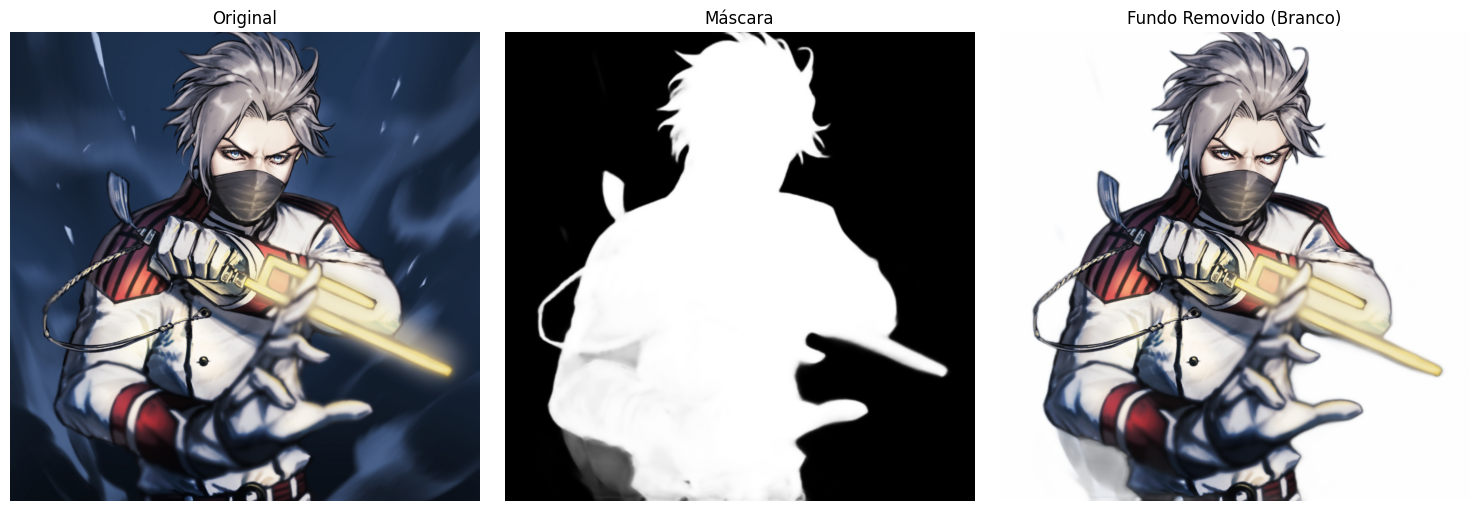

In [ ]:
# Visualizar resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Imagem original
img_original = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
axes[0].imshow(img_original)
axes[0].set_title('Original')
axes[0].axis('off')

# Máscara
axes[1].imshow(mask[:, :, 0], cmap='gray')
axes[1].set_title('Máscara')
axes[1].axis('off')

# Resultado com fundo branco
resultado_branco_rgb = cv2.cvtColor(resultado_branco, cv2.COLOR_BGR2RGB)
axes[2].imshow(resultado_branco_rgb)
axes[2].set_title('Fundo Removido (Branco)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Salvar resultado
cv2.imwrite('resultado_transparente.png', resultado_transparente)
cv2.imwrite('resultado_branco.png', resultado_branco)

print("✓ Imagens salvas!")

# Baixar resultados
files.download('resultado_transparente.png')
files.download('resultado_branco.png')

✓ Imagens salvas!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>